In [5]:
import matplotlib.pyplot as plt

from optimal_policy import Parameters, solve_optimal_policy, compute_outcomes, compute_welfare_vs_budget_allocation, \
    compare_beta_distributions, compare_welfare_vs_budget_allocation

                  COMPARISON ACROSS BELIEF VARIANCES                  
Mean belief: 1.00%

──────────────────────────────────────────────────────────────────────
Configuration 1: σ² = 0.000025
──────────────────────────────────────────────────────────────────────
  Beta parameters:      α = 3.95, β = 391.05

  WITHOUT INTERVENTION:
    Insurance threshold (q*): 1.01%
    Fraction insured:         42.6%
    Social welfare:           -1.015781

  OPTIMAL POLICY:
    Subsidy (s):              17.4%
    Relief (a):               0.0%
    Shadow value (λ):         2.229281

  OUTCOMES WITH OPTIMAL POLICY:
    Insurance threshold (q*): 0.83%
    Fraction insured:         57.4%
    Social welfare:           -1.013301
    Welfare gain:             0.002480

──────────────────────────────────────────────────────────────────────
Configuration 2: σ² = 0.000049
──────────────────────────────────────────────────────────────────────
  Beta parameters:      α = 2.01, β = 199.03

  WITHOUT INTERVENTIO

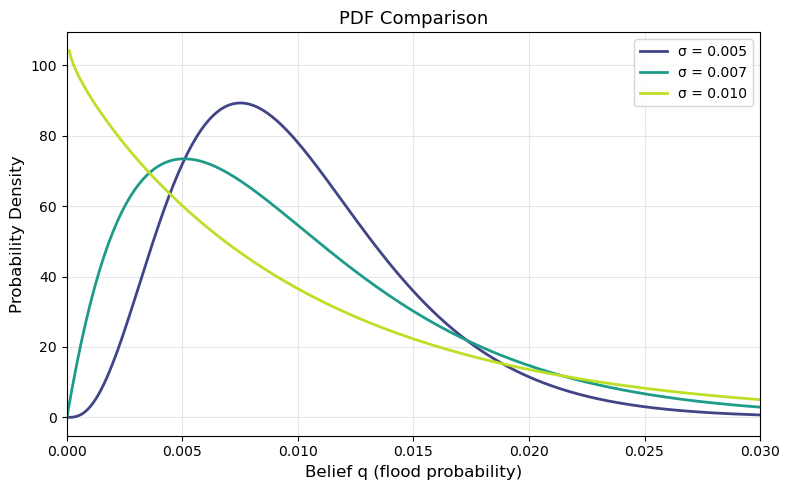

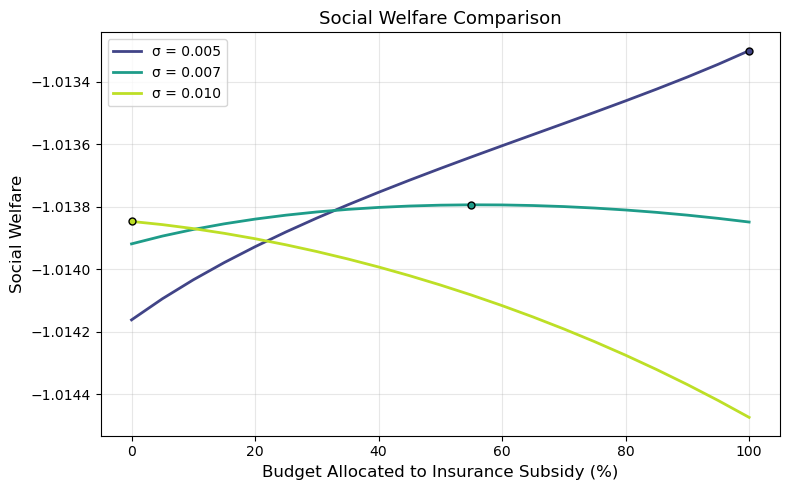

In [6]:
# Compare results across different belief variances
variances = [0.005**2, 0.007**2, 0.01**2]
mean_q = 0.01

# Create parameter sets
par_list = [Parameters(mean_q=mean_q, var_q=var, pi=0.02, gamma=2, B=0.001) for var in variances]
labels = [f'σ = {var**0.5:.3f}' for var in variances]

print("=" * 70)
print(f"{'COMPARISON ACROSS BELIEF VARIANCES':^70}")
print(f"Mean belief: {mean_q:.2%}")
print("=" * 70)

# Analyze each parameterization
results_list = []
for i, (par, var) in enumerate(zip(par_list, variances)):
    print(f"\n{'─' * 70}")
    print(f"Configuration {i+1}: σ² = {var:.6f}")
    print(f"{'─' * 70}")
    print(f"  Beta parameters:      α = {par.alpha:.2f}, β = {par.beta:.2f}")
    
    # No intervention outcomes
    outcomes_nogov = compute_outcomes(0., 0., par)
    print(f"\n  WITHOUT INTERVENTION:")
    print(f"    Insurance threshold (q*): {outcomes_nogov['q_star']:.2%}")
    print(f"    Fraction insured:         {outcomes_nogov['frac_insured']:.1%}")
    print(f"    Social welfare:           {outcomes_nogov['welfare']:.6f}")
    
    # Optimal policy
    s_opt, a_opt, lam_opt, converged = solve_optimal_policy(par)
    outcomes = compute_outcomes(s_opt, a_opt, par)
    
    print(f"\n  OPTIMAL POLICY:")
    print(f"    Subsidy (s):              {s_opt:.1%}")
    print(f"    Relief (a):               {a_opt:.1%}")
    print(f"    Shadow value (λ):         {lam_opt:.6f}")
    
    print(f"\n  OUTCOMES WITH OPTIMAL POLICY:")
    print(f"    Insurance threshold (q*): {outcomes['q_star']:.2%}")
    print(f"    Fraction insured:         {outcomes['frac_insured']:.1%}")
    print(f"    Social welfare:           {outcomes['welfare']:.6f}")
    print(f"    Welfare gain:             {outcomes['welfare'] - outcomes_nogov['welfare']:.6f}")
    
    # Compute welfare vs budget allocation for comparison
    results = compute_welfare_vs_budget_allocation(par, n_points=21)
    results_list.append(results)

print(f"\n{'=' * 70}")

# Compare distributions
print("\nGenerating comparison plots...")
fig1, ax1 = compare_beta_distributions(par_list, labels=labels, max_q=0.03)
#plt.savefig("pdf_comparison.png")

# Compare welfare functions
fig2, ax2 = compare_welfare_vs_budget_allocation(results_list, labels=labels)
#plt.savefig("welfare_comparison.png")